In [1]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import TensorDataset, DataLoader
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt

In [2]:
torch.cuda.is_available()

True

In [3]:
# Use GPU if it is avaialable
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [4]:
df = pd.read_csv("Climate_data.csv")

data = df.drop("Date Time" , axis=1)
column_label = data.columns.tolist()
data = torch.tensor(data.values , dtype=torch.float32)

mean = data.mean(dim=0)
std = data.std(dim=0)

data = (data - mean)/std

In [5]:
data[:72 , 1]

tensor([-2.0740, -2.1203, -2.1322, -2.1084, -2.1037, -2.0776, -2.0265, -2.0265,
        -2.0610, -2.1227, -2.1619, -2.1761, -2.1725, -2.1702, -2.1500, -2.1500,
        -2.1547, -2.1678, -2.1714, -2.1832, -2.1832, -2.1737, -2.1892, -2.1963,
        -2.2177, -2.2485, -2.2497, -2.2319, -2.2462, -2.2651, -2.2699, -2.2711,
        -2.2972, -2.2984, -2.2509, -2.2699, -2.2604, -2.2082, -2.1797, -2.1951,
        -2.2414, -2.2105, -2.1559, -2.1369, -2.1191, -2.1073, -2.0871, -2.0835,
        -2.0883, -2.0788, -2.0657, -2.0408, -2.0206, -2.0313, -2.0372, -2.0194,
        -1.9873, -1.9707, -1.9553, -1.9577, -1.9565, -1.9707, -1.9838, -1.9933,
        -1.9945, -2.0016, -2.0099, -1.9980, -1.9778, -1.9719, -1.9565, -1.9375])

In [ ]:
data_X = []
data_y = []

for i in range(len(data) - (72*6) - 1):
    data_X.append(data[i:i+(72*6)])
    data_y.append(data[i+(72*6)])
data_X = torch.stack(data_X)
data_y = torch.stack(data_y)

In [7]:
training_period = int(len(data_X) * 0.8)
data_X_train = data_X[:training_period]
data_y_train = data_y[:training_period]
data_X_test = data_X[training_period:]
data_y_test = data_y[training_period:]

In [8]:
print(len(data_X))

420118


In [9]:
dataset = TensorDataset(data_X_train , data_y_train)
loader = DataLoader(dataset , batch_size=5000 , shuffle=False)

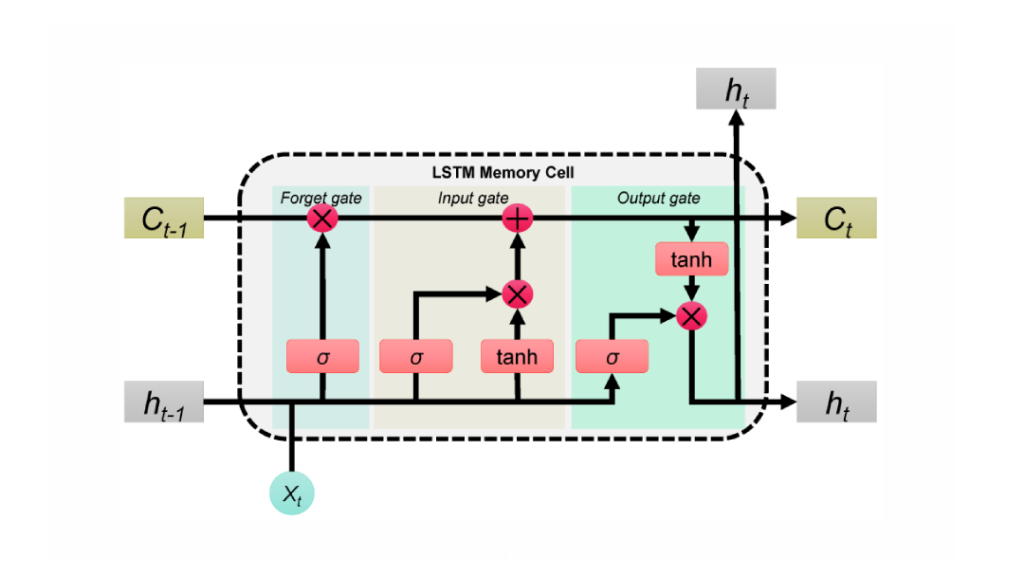

In [10]:
class LSTM_Layer(nn.Module):
    def __init__(self , input_dim , hidden_dim):
        super().__init__()
        

        # Forget Gate - How much of the current long term memory should be kept
        self.fg_input = nn.Linear(in_features=input_dim , out_features=hidden_dim)
        self.fg_memory = nn.Linear(in_features=hidden_dim , out_features=hidden_dim)

        # Input Gate - What is the new long term memory and how much of it do we have to remember
        self.ig_input_potmem = nn.Linear(in_features=input_dim , out_features=hidden_dim)
        self.ig_memory_potmem = nn.Linear(in_features=hidden_dim , out_features=hidden_dim)
        self.ig_input_perc = nn.Linear(in_features=input_dim , out_features=hidden_dim)
        self.ig_memory_perc = nn.Linear(in_features=hidden_dim , out_features=hidden_dim)

        # Output Gate - what should be the new short term memory seeing the current long term memory and current inputs
        self.og_input = nn.Linear(in_features=input_dim , out_features=hidden_dim)
        self.og_memory = nn.Linear(in_features=hidden_dim , out_features=hidden_dim)

    def forward(self , x , h , c):
        # h = hidden state (short term memory)
        # c = cell state (long term memory)


        # forget gate
        fg = self.fg_input(x) + self.fg_memory(h)
        fg = torch.sigmoid(fg)
        c = c*fg

        # Input Gate
        ig_potmem = self.ig_input_potmem(x) + self.ig_memory_potmem(h)
        ig_potmem = torch.tanh(ig_potmem)
        ig_perc = self.ig_input_perc(x) + self.ig_memory_perc(h)
        ig_perc = torch.sigmoid(ig_perc)
        ig = ig_potmem * ig_perc
        c = c + ig

        # Output Gate
        og = self.og_input(x) + self.og_memory(h)
        og = torch.sigmoid(og)
        h = torch.tanh(c) * og
    
        return h,c
    


class LSTM(nn.Module):
    def __init__(self , hidden_dim):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.Layer1 = LSTM_Layer(14 , hidden_dim)
        # self.Layer2 = LSTM_Layer(hidden_dim , hidden_dim)    # for if you need two layers
        self.final = nn.Linear(in_features=hidden_dim , out_features=14)

    def forward(self , x):
        h1 = torch.zeros(x.shape[0],self.hidden_dim).to(device)
        c1 = torch.zeros(x.shape[0],self.hidden_dim).to(device)
        # h2 = torch.zeros(x.shape[0],self.hidden_dim).to(device)   # for if you need two layers
        # c2 = torch.zeros(x.shape[0],self.hidden_dim).to(device)   # for if you need two layers
        x = x.to(device)

        for i in range(x.shape[1]):
            h1,c1 = self.Layer1(x[:,i,:] , h1 , c1)
            # h2,c2 = self.Layer2(h1 , h2 , c2)     # for if you need two layers
        y_pred = self.final(h1)     
        # y_pred = self.final(h2)   # for if you need two layers also comment out the upper line
        return y_pred

In [25]:
torch.manual_seed(12)
Model = LSTM(32).to(device)
loss_fn = nn.MSELoss()
optimizer = Adam(Model.parameters() , lr=1e-3 , weight_decay=1e-4)

losses = []
epochs = 10

for epoch in range(epochs):
    running_loss = 0
    batch = 1
    for X,y in loader:
        y_pred = Model(X)
        loss = loss_fn(y_pred,y.to(device))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss = running_loss + loss.item()
        print(f"Epoch : {epoch+1}\tBatch : {batch}/{len(loader)}\tLoss : {loss.item()}")
        batch = batch+1
    losses.append(running_loss/len(loader))
    print(f"----------Epoch : {epoch+1}\tAverage Loss in Entire Epoch : {running_loss/len(loader)}----------\n")

Epoch : 1	Batch : 1/68	Loss : 1.6938227415084839
Epoch : 1	Batch : 2/68	Loss : 0.8719114065170288
Epoch : 1	Batch : 3/68	Loss : 0.6558309197425842
Epoch : 1	Batch : 4/68	Loss : 0.5043168663978577
Epoch : 1	Batch : 5/68	Loss : 0.5807027816772461
Epoch : 1	Batch : 6/68	Loss : 1.1959705352783203
Epoch : 1	Batch : 7/68	Loss : 1.2543421983718872
Epoch : 1	Batch : 8/68	Loss : 0.5432382822036743
Epoch : 1	Batch : 9/68	Loss : 0.4224608242511749
Epoch : 1	Batch : 10/68	Loss : 0.43457600474357605
Epoch : 1	Batch : 11/68	Loss : 1.483617901802063
Epoch : 1	Batch : 12/68	Loss : 1.4631783962249756
Epoch : 1	Batch : 13/68	Loss : 0.7987567186355591
Epoch : 1	Batch : 14/68	Loss : 0.529146671295166
Epoch : 1	Batch : 15/68	Loss : 0.47120869159698486
Epoch : 1	Batch : 16/68	Loss : 1.4404902458190918
Epoch : 1	Batch : 17/68	Loss : 1.2424230575561523
Epoch : 1	Batch : 18/68	Loss : 0.5531198382377625
Epoch : 1	Batch : 19/68	Loss : 0.33954882621765137
Epoch : 1	Batch : 20/68	Loss : 0.5091168880462646
Epoch : 

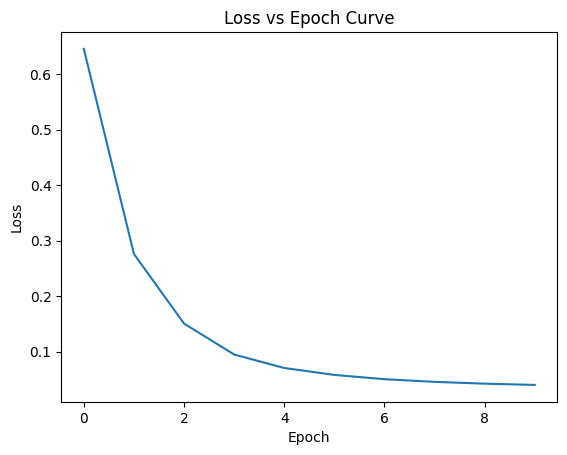

In [26]:
plt.plot(losses)
plt.title("Loss vs Epoch Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [27]:
# Saving model weights
weights = Model.state_dict()
with open("LSTM_model_weights.pkl","wb") as F:
    pickle.dump(weights , F)

In [28]:
# Seeing all the values predicted and actual values to see how close they are
with torch.no_grad():
    y_pred = Model(data_X_test)
    y_pred = y_pred.cpu()
    df1 = pd.DataFrame((data_y_test*std + mean).numpy())
    df2 = pd.DataFrame((y_pred*std + mean).numpy())
    df1.columns = column_label
    df2.columns = column_label
    df1,df2

In [35]:
with torch.no_grad():
    print("MSE Loss : ",loss_fn(y_pred , data_y_test).item())
    print("MAE Loss : ",nn.L1Loss()(y_pred , data_y_test).item())
    print("Huber Loss : ",nn.HuberLoss()(y_pred , data_y_test).item())

MSE Loss :  0.7540854215621948
MAE Loss :  0.08636905252933502
Huber Loss :  0.0216409619897604


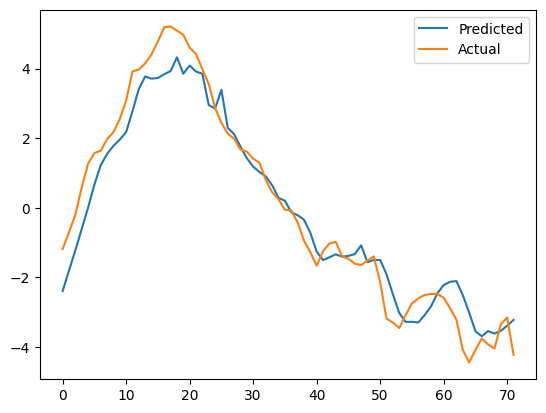

In [41]:
plt.plot(y_pred[-72:,1]*std[1] + mean[1] , label="Predicted")
plt.plot(data_y_test[-72:,1]*std[1] + mean[1] , label="Actual")
plt.legend()
plt.show()

In [51]:
print((df2-df1).min())
print("\n")
print((df2-df1).max())

p (mbar)            -8.882568
T (degC)            -7.201281
Tpot (K)            -7.665527
Tdew (degC)         -3.438581
rh (%)             -32.912029
VPmax (mbar)       -20.710770
VPact (mbar)        -4.844538
VPdef (mbar)       -20.832493
sh (g/kg)           -2.737640
H2OC (mmol/mol)     -5.371326
rho (g/m**3)       -20.778198
wv (m/s)           -28.673464
max. wv (m/s)      -24.717346
wd (deg)          -336.421936
dtype: float32


p (mbar)               7.121338
T (degC)               5.607334
Tpot (K)               6.054016
Tdew (degC)            4.675800
rh (%)                28.681335
VPmax (mbar)           8.194101
VPact (mbar)           3.410756
VPdef (mbar)          11.558477
sh (g/kg)              2.215043
H2OC (mmol/mol)        3.675551
rho (g/m**3)          30.985107
wv (m/s)            9999.228516
max. wv (m/s)      10002.889648
wd (deg)             311.108521
dtype: float32


In [30]:
df2

,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,987.045898,15.485596,289.688690,11.716789,78.957123,16.907564,13.561028,3.358473,8.627645,13.622847,1185.681396,2.806007,4.065899,164.069107
1,986.945007,15.863827,290.220306,11.589889,76.947716,17.194233,13.455500,3.843756,8.581289,13.527655,1184.288208,3.120209,4.711573,172.906525
2,986.819031,16.207361,290.875244,11.055823,73.562187,17.453691,13.031652,4.679945,8.328593,13.126492,1183.226318,3.607789,5.707143,191.670715
3,987.582764,16.455074,290.478210,10.998240,72.767807,17.813330,13.073196,4.886133,8.224108,13.093634,1182.507080,2.455346,3.325958,120.435089
4,987.975952,16.066721,289.782684,10.936188,73.650581,17.472694,13.105909,4.467547,8.184834,13.069234,1185.109863,2.462615,2.035125,86.680222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84019,1000.726135,-3.546811,269.209625,-6.918186,75.362038,4.681934,3.493029,1.123923,2.331155,3.408819,1290.890503,2.874756,4.021994,196.312302
84020,1000.579590,-3.620216,269.231445,-7.157532,74.498528,4.585193,3.354746,1.174092,2.246593,3.242230,1291.509155,2.985903,4.732641,197.483002
84021,1000.272644,-3.536656,269.481812,-7.126458,74.022552,4.708454,3.343348,1.302132,2.247995,3.294589,1290.307251,3.060333,5.080333,211.784729
84022,1000.177063,-3.394367,269.837524,-7.240481,72.285568,4.825274,3.251853,1.451796,2.217379,3.186408,1289.362549,3.173285,5.895756,217.851532
